# Example: Using single point fitting parameters for warm start fitting of mapping datasets from MoS2 monolayer sample

The next example show how to pass the fitting paramters `p0` of single point fitting for mapping to achieve warm start fitting. There are two ways to do this:

1. Use a single point fit of the mapping dataset as the seed (recommended for mapping datasets with similar spectra across the map). See the *Mapping/Mapping PL Example.ipynb* for details.

2. Use the fitted parameters from a single point fit of a different dataset (e.g., a point fit from a similar sample) as the seed (recommended for mapping datasets with spectra that are significantly different from each other, e.g., due to inhomogeneity across the map) See the example code below for details.

D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\preprocessing.py:205: FutureWarning: 
Using 'baseline_method="poly"' together with legacy parameters (poly_degree / gaussian_sigma) is deprecated and will be removed in a future version.
Please use:
  baseline_method=("poly", value)
or:
  baseline_method={'method': 'poly', 'param': value}
  method, bkwargs = BaselineAPI.parse_spec(
D:\OneDrive - University of Cambridge\9 Expt results\Raman\00A_data_analysis_source code\RamanPL_2D\src\ramanpl\Mapping.py:493: FutureWarning: 
Using 'baseline_method="poly"' together with legacy parameters (poly_degree / gaussian_sigma) is deprecated and will be removed in a future version.
Please use:
  baseline_method=("poly", value)
or:
  baseline_method={'method': 'poly', 'param': value}
  self._baseline_method, self._baseline_kwargs = BaselineAPI.parse_spec(


Fitted parameters:
 {'p0': array([1.87917789, 0.00268928, 0.00747293, 1.82300654, 0.00970094,
       0.01198451]), 'peak_order': ['Exciton', 'Trion']}
Successful fits: 2115 / 2115


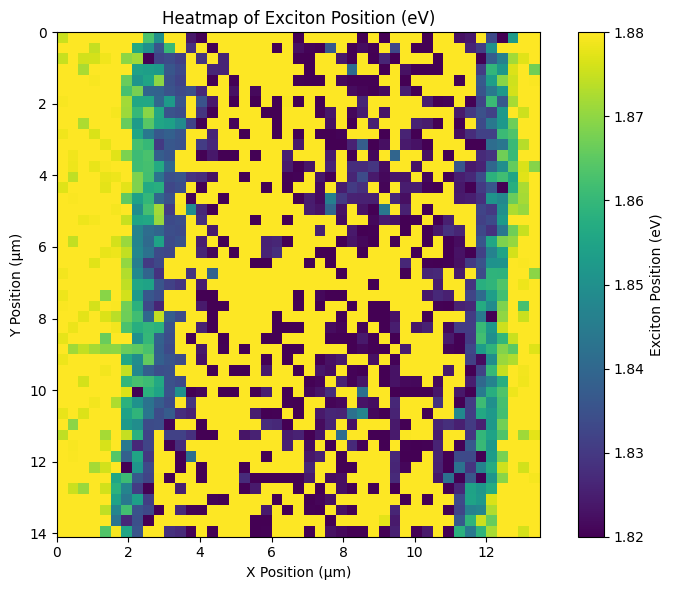

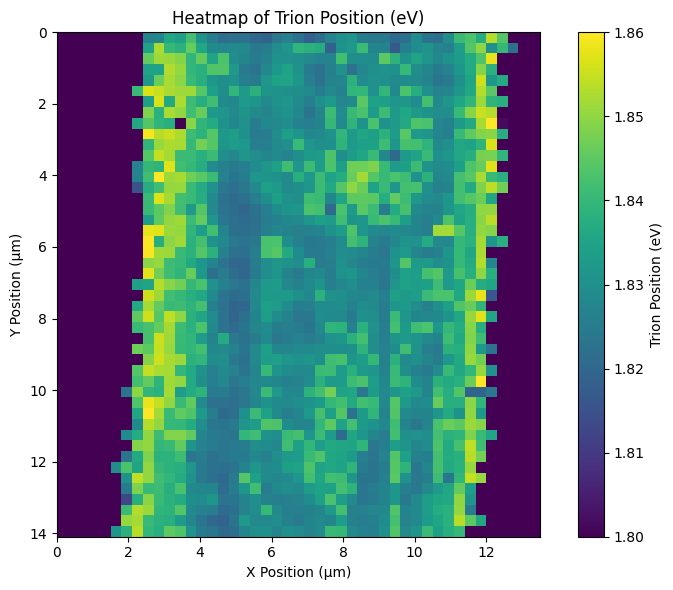

In [2]:
from ramanpl import PLfit

# Import data from WDF file
intensity, energy = PLfit.DataImporter.data_import(
    filename='PL Sample MoS2 2D Flakes.wdf',
    x_range=(1.74, 1.88)
)

# Use custom peak names and export fitted parameters for Mapping usage
custom_peaks = {
    "Exciton": ([1.82, 0, 0], [1.88, 0.05, 0.1]),
    "Trion":   ([1.80, 0, 0], [1.86, 0.05, 0.05]),
}

## Make sure to run other cells above first to import data and instantiate PLfit class ##
pl_fit = PLfit.PLfit(
    spectra=intensity,
    energy=energy,
    background_remove=True,
    smoothing=False,
    normalize=False,               # display only
    custom_peaks=custom_peaks,
    peak_order=list(custom_peaks.keys())  # ["Exciton","Trion"]
)

params, _ = pl_fit.fit_spectrum()
p0_pkg = pl_fit.export_p0()

# Display fitted parameters
print(f"Fitted parameters:\n", p0_pkg)

# Put the single-point fitted parameters into a p0 for Mapping.py usage
# this optional step help to improve fitting efficiency and stability
from ramanpl import Mapping
data_range_ev = (1.74, 1.92)  # use eV limits (recommended)

pl_map = Mapping.PLMapping(
    filename="Mapping PL MoS2 Lines.txt",
    custom_peaks=custom_peaks,
    step_size=0.3,
    poly_degree=1,
    background_remove=True,
    smoothing=False,
    baseline_method="poly",
    data_range=data_range_ev,
    normalize=False  # affects display only
)
# --- Mapping fit using p0 seed + warm-start
pl_map.fit_spectra(initial_p0=p0_pkg, warm_start=True, reset_on_fail=True)

# Heatmaps
pl_map.plot_heatmap(data_type="exciton_position")
pl_map.plot_heatmap(data_type="trion_position")